In [2]:
header = "D:/K_sunada/result/CDY152/"

## 11_27 fogi calibration - DPR1-L-120-44

In [3]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [4]:
import sklearn
from sklearn.decomposition import PCA

In [4]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

In [5]:
fogi = "/2023-11-14/2023-11-14T114020_275a8990-40_fogi_frequency_sweep"
dd_fogi = datadict_from_hdf5(header + fogi +"/data")


ValueError: Specified file does not exist.

In [9]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [ ]:
Fogi = dd_fogi['s11']['values']
#imag_ge = Rabi_ge.imag
Fogi_freq = dd_fogi['fogi_freq']['values']

I = (Fogi.real)
Q = (Fogi.imag)

PCAfogi = PCA_transform(I, Q)

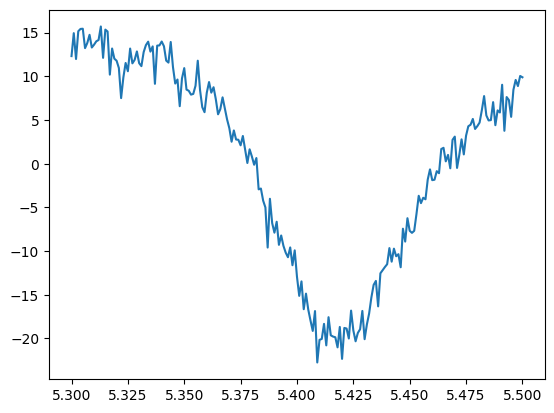

In [ ]:
y = PCAfogi[0]
x = Fogi_freq

plt.plot(x, -y)
plt.show()

In [ ]:
par_ini = {
    'amp': 35,
    'const':13,
    'center':5.425,
    'k':0.025
}

par_min = {
    'amp': 0,
    'const':-np.inf,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [ ]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [ ]:
result = model.fit(data = -y, params=params, freq = x)
result

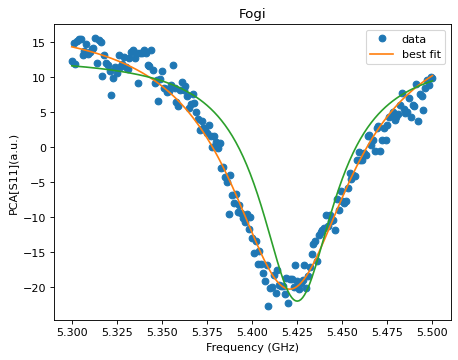

In [ ]:
fig, ax = plt.subplots(dpi=80)

plt.title("Fogi")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(x,result.init_fit)


plt.xlabel("Frequency (GHz)")
plt.ylabel("PCA[S11](a.u.)")

plt.show()

## ac stark shift

In [29]:
def double_Lorentzian(freq, amp1, const, center1, k1, amp2, center2, k2):
    return const - amp1*k1**2/((freq-center1)**2 + k2**2)- amp2*k2**2/((freq-center2)**2 + k2**2)

In [30]:
ac = "/2023-11-27/2023-11-27T104900_22b27732-42_fogi_ac_Stark_shift"
dd_ac = datadict_from_hdf5(header + ac +"/data")

xs = []
ys = []

for i in range(11):
    ini = 71*i
    fin = 71*(1+i)
    x = dd_ac['fogi_freq']['values'][ini:fin]
    y = dd_ac['s11']['values'][ini:fin].real
    xs.append(x)
    ys.append(y)

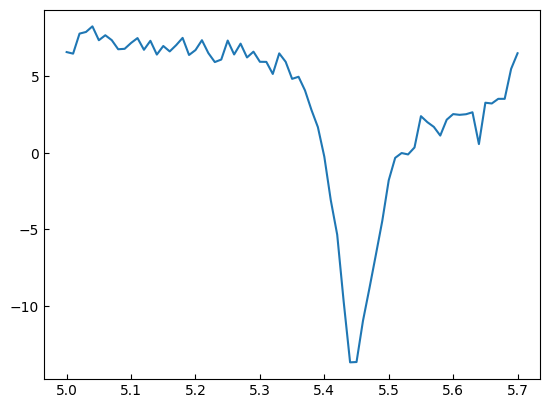

In [31]:
plt.plot(xs[0], -ys[0])
plt.show()

In [32]:
par_ini = {
    'amp1': 60,
    'const':7,
    'center1':5.35,
    'k1':0.07,
    'amp2': 3,
    'center2':5.5,
    'k2':0.12,
}

par_min = {
    'amp1': 0,
    'const':-np.inf,
    'center1':0,
    'k1':0,
    'amp2': 0,
    'center2':0,
    'k2':0,
}

par_max = {
    'amp1': np.inf,
    'const':np.inf,
    'center1':np.inf,
    'k1':np.inf,
    'amp2': np.inf,
    'center2':np.inf,
    'k2':np.inf,
}

par_vary = {
    'amp1': True,
    'const':True,
    'center1':True,
    'k1':True,
    'amp2': True,
    'center2':True,
    'k2':True,
}

In [33]:
model = lmfit.Model(double_Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [34]:
results = []
for i in range(10):
    result = model.fit(data = -ys[i], params=params, freq = xs[i])
    results.append(result)

In [53]:
results[4]

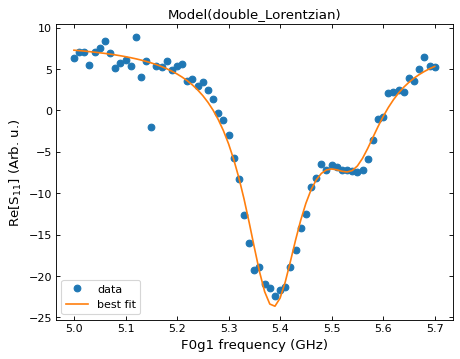

In [57]:
fig, ax = plt.subplots(dpi=80)


plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

results[4].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
ax.set_xlabel('F0g1 frequency (GHz)', size='large')
ax.set_ylabel('Re[S$_{11}$] (Arb. u.)', size='large')
plt.show()

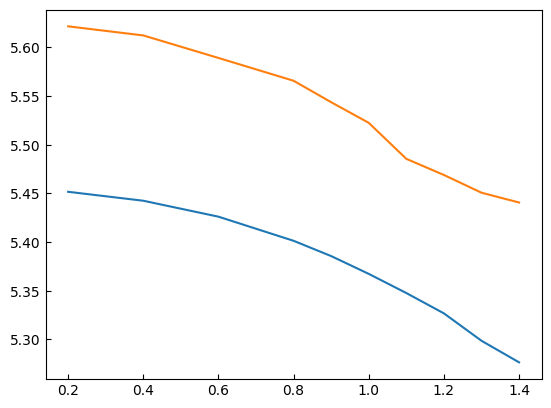

In [37]:
x =[ 0.2, 0.4, 0.6, 0.8, 0.9, 
     1.0, 1.1, 1.2, 1.3, 1.4]
y1 =[5.45170904, 5.44252632, 5.42614787, 5.40136339, 5.38567228, 
     5.36739227, 5.34771135, 5.32682746, 5.29869813, 5.27653596]
y2 =[5.62165854, 5.61231752, 5.58917815, 5.56575065, 5.54371784,
     5.52253094, 5.48555466, 5.46898425, 5.45077474, 5.44070221]

plt.plot(x, y1)
plt.plot(x, y2)
plt.show()

In [38]:
def ac_stark(amp, const, alpha):
    return const - alpha*(amp**2)

In [39]:
par_ini = {
    'const':5.45,
    'alpha':0.14
}

par_min = {
    'const':0,
    'alpha':-np.inf
}

par_max = {
    'const':np.inf,
    'alpha':np.inf
}

par_vary = {
    'const':True,
    'alpha':True
}

In [40]:
model = lmfit.Model(ac_stark)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [41]:
result = model.fit(data = y1, params=params, amp = x)
result

In [42]:
result2 = model.fit(data = y2, params=params, amp = x)
result2

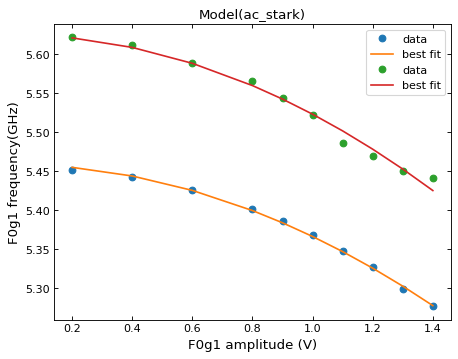

In [60]:
fig, ax = plt.subplots(dpi=80)

plt.rcParams["font.size"] = 10
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )


plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
result2.plot_fit(ax = ax)
# plt.plot(x ,result.init_fit)

plt.xlabel("F0g1 amplitude (V)", size = "large")
plt.ylabel("F0g1 frequency(GHz)", size = "large")



plt.show()

In [44]:
(0.09246521+0.10209789)/2

0.09728155

fogi duration

In [61]:
fogi_duration = "/2023-11-27/2023-11-27T124156_e994318a-41_fogi_duration_sweep"
dd_fogi_duration = datadict_from_hdf5(header + fogi_duration +"/data")

In [64]:
x_duration = dd_fogi_duration['fogi_duration']['values']
y_duration = dd_fogi_duration['s11']['values']

PCAduration = PCA_transform(y_duration.real, y_duration.imag)

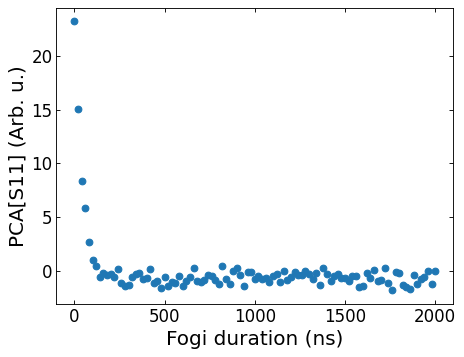

In [70]:
fig, ax = plt.subplots(dpi=80)

#plt.title("fogi duration")
plt.rcParams["font.size"] = 15
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.scatter(x_duration ,PCAduration[0])

plt.xlabel("Fogi duration (ns)", size="large")
plt.ylabel("PCA[S11] (Arb. u.)", size="large")
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

plt.show()

In [ ]:
def ave_ph_number(alpha):
    return np.exp(-(alpha**2)/2)*alpha

In [23]:
ph_amp = "/2023-11-30/2023-11-30T174155_50e3db80-61_ab1_ph_amp_sweep"
dd_ph_amp = datadict_from_hdf5(header + ph_amp +"/data")

In [24]:
x = dd_ph_amp['photon_amp']['values']
y = dd_ph_amp['s11']['values'].real

In [21]:
PCA_ph_amp = PCA_transform(y.real, y.imag)
y = PCA_ph_amp[0]

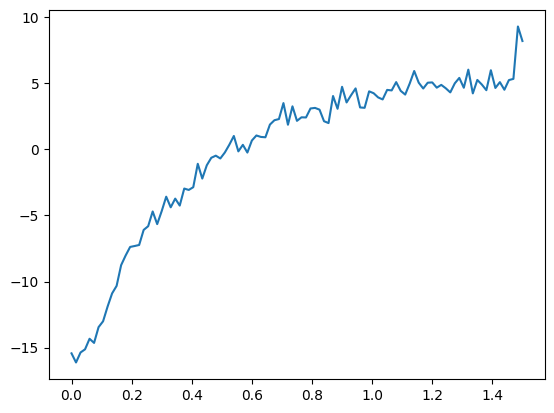

In [11]:
plt.plot(x, -y)
plt.show()

In [12]:
def ave_ph_number(ph_amp, amp, const, a):
    return const + amp*np.exp(-(a*ph_amp)**2)*(a*ph_amp)**2

In [13]:
par_ini = {'amp': 150,'const':-40, 'a':2}
par_min = {'amp': 0, 'const':-np.inf, 'a':0}
par_max = {'amp': np.inf,'const':np.inf, 'a':np.inf}
par_vary = {'amp': True,'const':True, 'a':True}

In [ ]:
model = lmfit.Model(ave_ph_number)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [ ]:
result = model.fit(data = -y, params=params, ph_amp = x)
result


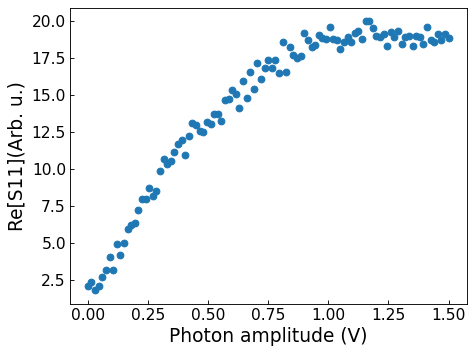

In [26]:
fig, ax = plt.subplots(dpi=80)
# plt.title("ph_amp")
plt.rcParams["font.size"] = 14
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
# result.plot_fit(ax = ax)
# plt.plot(x,result.init_fit)
plt.scatter(x, y)


plt.xlabel("Photon amplitude (V)", size="large")
plt.ylabel("Re[S11](Arb. u.)", size="large")

plt.show()

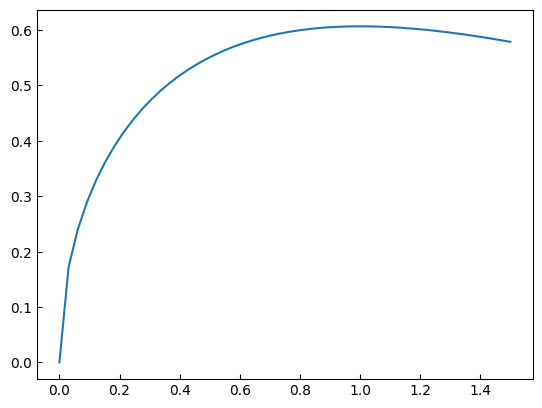

In [ ]:
x = np.linspace(0, 1.5)
plt.plot(x, ave_ph_number(x**0.5))
plt.show()